# Stellaris Lifetime Plotter
**By Sebastian Palacios Martinez**

This notebook plots fit lifetime data from LASX. It requires a `.csv` file with lifetime data per cell/frame as individual rows.

### Required columns in the CSV:
- `Name`
- `Time`
- `Region`
- `Mean τ, Intensity Weighted  ns`
- `Mean τ, Amplitude Weighted ns`
- `χ²`

## 1. Imports

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from cycler import cycler

## 2. Configuration
Set the working directory, filename, and lifetime weighting type here.

In [14]:
#### Set folder where data is located ####
data_folder = './'
os.chdir(data_folder)

#### Set filename to import and to use as plot title ####
filename = 'TL2_3componentFit.csv'

#### Choose which lifetime weight to plot: 'amp' (Amplitude) or 'int' (Intensity) ####
lifetime = 'amp'


## 3. Load and Clean Data

In [24]:
# Load full CSV first
df = pd.read_csv(filename, index_col='Region')

# Force column names
df.columns = ['Number', 'Name', 'Channel', 'Time', 'Tail Offset Cnts', 'Amplitude 1 kCnts', 
               'Amplitude 2 kCnts', 'Amplitude 3 kCnts', 'Lifetime (τ) 1 ns', 'Lifetime (τ) 2 ns', 
               'Lifetime (τ) 3 ns', 'IRF Background Cnts', 'IRF Shift ns', 'Intensity 1 kCnts', 
               'Intensity 2 kCnts', 'Intensity 3 kCnts', 'Sum Amplitudes kCnts', 'Sum Intensity kCnts', 
               'Mean tau Intensity Weighted ns', 'Mean tau Amplitude Weighted ns', 'χ²', 'x', 'y', 'z']

# Select only the necessary columns
columns_to_keep = ['Name', 'Time', 'Mean tau Intensity Weighted ns', 'Mean tau Amplitude Weighted ns', 'χ²']
df = df[columns_to_keep]

# Remove overall Decay row if present
df = df[df.index != 'Overall Decay']

# Replace 'ROI' with 'Cell' in the index
df.index = df.index.str.replace('ROI', 'Cell', regex=False)

# Convert time strings to float (strip last 2 characters, e.g. ' s')
df['TimeFixed2'] = df['Time'].str[:-2].astype(float)

df.head()

,Name,Time,Mean tau Intensity Weighted ns,Mean tau Amplitude Weighted ns,χ²,TimeFixed2
Region,,,,,,
Cell 1,TL_HUVEC_FLITS_Histamine,0.000 s,4.087573,3.696775,1.447921,0.0
Cell 2,TL_HUVEC_FLITS_Histamine,0.000 s,4.081280,3.640646,1.237539,0.0
Cell 3,TL_HUVEC_FLITS_Histamine,0.000 s,4.079749,3.682346,1.239860,0.0
Cell 4,TL_HUVEC_FLITS_Histamine,0.000 s,4.058715,3.678956,1.540670,0.0
Cell 5,TL_HUVEC_FLITS_Histamine,0.000 s,4.093170,3.683712,1.051303,0.0


## 4. Select Lifetime Variable

In [27]:
if lifetime == 'amp':
    pvar = 'Amplitude'
    mean_per_time = df.groupby('TimeFixed2')['Mean tau Amplitude Weighted ns'].mean().reset_index()
elif lifetime == 'int':
    pvar = 'Intensity'
    mean_per_time = df.groupby('TimeFixed2')['Mean tau Intensity Weighted ns'].mean().reset_index()
else:
    raise ValueError("lifetime weight must be either 'amp' or 'int'")

target_col = f"Mean tau {pvar} Weighted ns"
print(f"Plotting: {target_col}")

Plotting: Mean tau Amplitude Weighted ns


## 5. Outlier Removal (IQR Method)
Threshold between 0.5–1.5 is suitable for removing data when the arm is lifted. Set to `100` to effectively disable outlier removal.

In [28]:
def remove_outliers(df, col, group_col='Region', threshold=100):
    """Removes outliers from df[col] grouped by group_col using IQR method."""
    clean_df = pd.DataFrame()
    for region, group in df.groupby(group_col):
        Q1 = group[col].quantile(0.25)
        Q3 = group[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        filtered_group = group[(group[col] >= lower_bound) & (group[col] <= upper_bound)]
        clean_df = pd.concat([clean_df, filtered_group])
    return clean_df

df = remove_outliers(df, target_col)

# Recompute mean per time on cleaned data
mean_per_time = df.groupby('TimeFixed2')[target_col].mean().reset_index()

print(f"Rows after outlier removal: {len(df)}")

Rows after outlier removal: 600


## 6. Plot

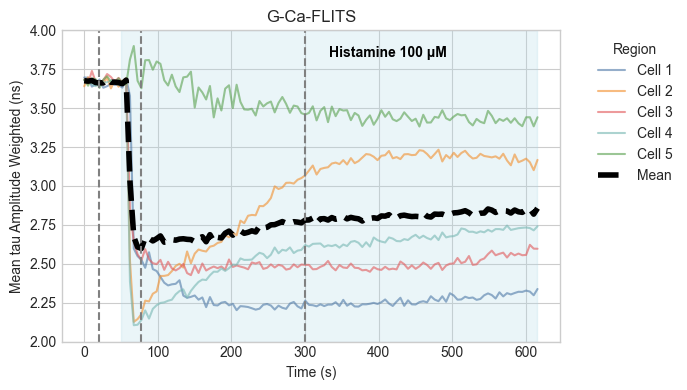

In [29]:
def add_treatment_boxes(treatments):
    """
    Draw shaded boxes and labels for treatments.
    
    Parameters
    ----------
    treatments : list of dict
        Each dict should have:
        - 'start' (float): start time in seconds
        - 'end'   (float): end time in seconds
        - 'label' (str)  : text to display inside the box
        - 'color' (str)  : matplotlib color (optional, default 'lightgray')
        - 'alpha' (float): transparency 0–1 (optional, default 0.3)
    """
    for t in treatments:
        color = t.get('color', 'lightgray')
        alpha = t.get('alpha', 0.3)
        plt.axvspan(t['start'], t['end'], color=color, alpha=alpha)
        plt.text(
            (t['start'] + t['end']) / 2,
            plt.ylim()[1] - 0.05 * (plt.ylim()[1] - plt.ylim()[0]),
            t['label'],
            ha='left', va='top',
            fontsize=10,
            color='black',
            fontweight='bold'
        )


# --- Style ---
plt.figure(figsize=(7, 4))
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.prop_cycle'] = cycler(color=[
    '#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F',
    '#EDC948', '#B07AA1', '#FF9DA7', '#9C755F', '#BAB0AC'
])

# --- Plot each cell/region ---
for region, group in df.groupby(df.index):
    plt.plot(group['TimeFixed2'], group[target_col], label=f'{region}', alpha=0.6)

# --- Mean line ---
plt.plot(
    mean_per_time['TimeFixed2'], mean_per_time[target_col],
    color='black', linewidth=4, linestyle='--', label='Mean'
)

# --- Axis limits ---
if lifetime == 'amp':
    plt.ylim(2.0, 4.0)
else:
    plt.ylim(3.0, 4.5)

plt.xlabel('Time (s)')
plt.ylabel(f'Mean tau {pvar} Weighted (ns)')
plt.title('G-Ca-FLITS')
plt.grid(True)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

# --- Vertical reference lines ---
plt.axvline(x=20.7, color='grey', linewidth=1.5, linestyle='--')
plt.axvline(x=77,   color='grey', linewidth=1.5, linestyle='--')
plt.axvline(x=300,  color='grey', linewidth=1.5, linestyle='--')

plt.tight_layout()  # Call before treatment boxes so labels aren't shifted

# --- Treatment boxes ---
treatments = [
    {'start': 50, 'end': 615, 'label': 'Histamine 100 μM', 'color': 'lightblue', 'alpha': 0.25},
    # {'start': 380, 'end': 730, 'label': 'F+I', 'color': 'lightblue', 'alpha': 0.5},
]
add_treatment_boxes(treatments)

plt.show()